In [1]:
!pip install datasets

In [2]:
!pip install imblearn

In [3]:
!pip install pandarallel

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import spacy
import datasets
from pandarallel import pandarallel

In [5]:
from datasets import load_dataset
ds = load_dataset("Yelp/yelp_review_full")

In [6]:
ds

DatasetDict({
    train: Dataset({
        features: ['label', 'text'],
        num_rows: 650000
    })
    test: Dataset({
        features: ['label', 'text'],
        num_rows: 50000
    })
})

In [7]:
df1=pd.DataFrame({
    'text':ds['train']['text'],
    'label':ds['train']['label']
})
df1.head()

,text,label
0,dr. goldberg offers everything i look for in a...,4
1,"Unfortunately, the frustration of being Dr. Go...",1
2,Been going to Dr. Goldberg for over 10 years. ...,3
3,Got a letter in the mail last week that said D...,3
4,I don't know what Dr. Goldberg was like before...,0


In [8]:
df1.shape

(650000, 2)

In [9]:
df2=pd.DataFrame({
    'text':ds['test']['text'],
    'label':ds['test']['label']
})
df2.head()

,text,label
0,I got 'new' tires from them and within two wee...,0
1,Don't waste your time. We had two different p...,0
2,All I can say is the worst! We were the only 2...,0
3,I have been to this restaurant twice and was d...,0
4,Food was NOT GOOD at all! My husband & I ate h...,0


In [10]:
df2.shape

(50000, 2)

In [11]:
df=pd.concat([df1,df2],ignore_index=True)

In [12]:
df.head()

,text,label
0,dr. goldberg offers everything i look for in a...,4
1,"Unfortunately, the frustration of being Dr. Go...",1
2,Been going to Dr. Goldberg for over 10 years. ...,3
3,Got a letter in the mail last week that said D...,3
4,I don't know what Dr. Goldberg was like before...,0


In [13]:
df.shape

(700000, 2)

In [14]:
df=df.sample(frac=1,random_state=9426).reset_index(drop=True)
df

,text,label
0,Don't waste ur time and money here !!! The foo...,0
1,I love this place. The pho is great and consis...,3
2,Our fav pizza spot in Pittsburgh! 1/2 butcher ...,4
3,"Good pizza, definitely better than the nationa...",2
4,I'm not Greek or Middle Eastern. I'm not that...,1
...,...,...
699995,For those Vegas locals who rarely if ever vent...,1
699996,This place was awesome. It was my first time t...,4
699997,"Not bad, not great. Would I eat here again? Wh...",2
699998,I knew this place must be good since I arrived...,4


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700000 entries, 0 to 699999
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    700000 non-null  object
 1   label   700000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 10.7+ MB


In [16]:
df.describe()

,label
count,700000.000000
mean,2.000000
std,1.414215
min,0.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,4.000000


In [17]:
df.isna().sum()

text     0
label    0
dtype: int64

In [18]:
labels_count=df['label'].value_counts()
labels_count

label
0    140000
3    140000
4    140000
2    140000
1    140000
Name: count, dtype: int64

In [19]:
pandarallel.initialize(progress_bar=True)

INFO: Pandarallel will run on 8 workers.
INFO: Pandarallel will use standard multiprocessing data transfer (pipe) to transfer data between the main process and workers.

https://nalepae.github.io/pandarallel/troubleshooting/


In [20]:
def labels_to_sentiment(label):
    if label in [0,1]:
        return 0
    elif label==2:
        return 1
    else:
        return 2

In [21]:
df['sentiment']=df['label'].parallel_apply(labels_to_sentiment)
df['sentiment']

0         0
1         2
2         2
3         1
4         0
         ..
699995    0
699996    2
699997    1
699998    2
699999    0
Name: sentiment, Length: 700000, dtype: int64

In [22]:
sentiment_count=df['sentiment'].value_counts()
sentiment_count

sentiment
0    280000
2    280000
1    140000
Name: count, dtype: int64

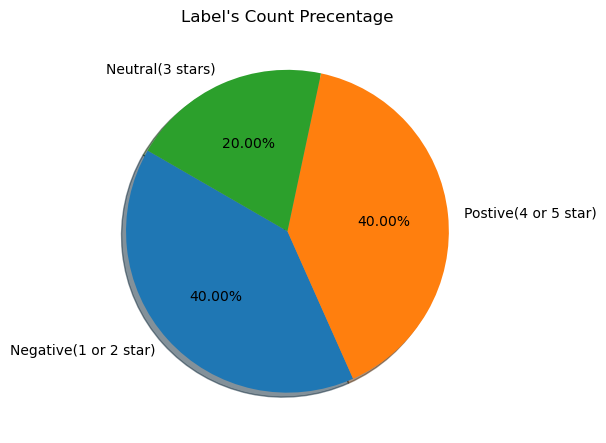

In [23]:
plt.figure(figsize=(6,6))
labels=["Negative(1 or 2 star)","Postive(4 or 5 star)","Neutral(3 stars)"]
plt.pie(
    sentiment_count,
    labels=labels,
    autopct="%1.2f%%",
    shadow=True,
    startangle=150
)
plt.title("Label's Count Precentage")
plt.tight_layout()
plt.show()

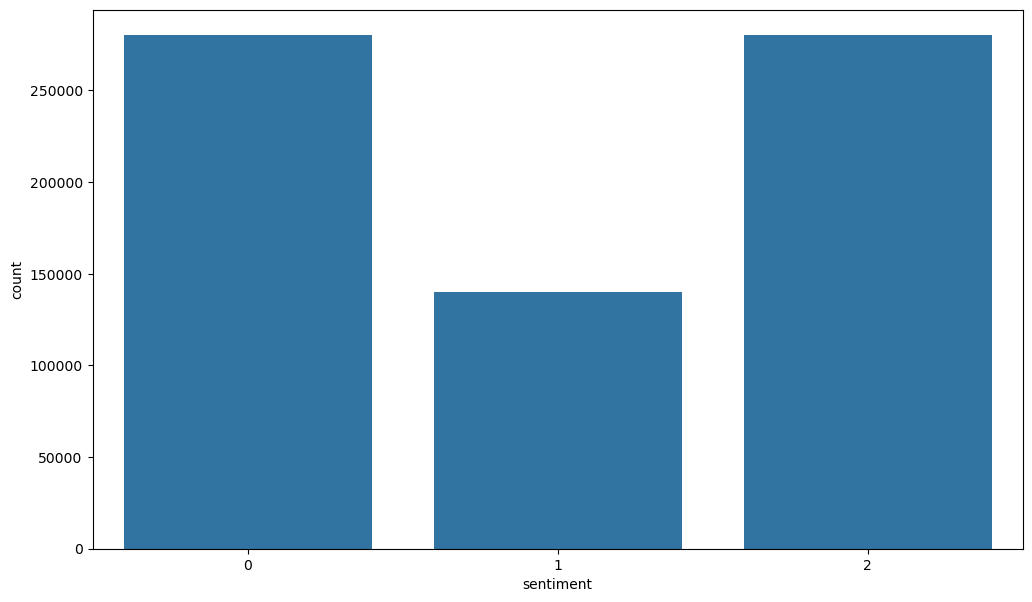

In [24]:
plt.figure(figsize=(12,7))
sns.countplot(
    data=df,
    x='sentiment'
)
plt.show()

In [25]:
df['text']

0         Don't waste ur time and money here !!! The foo...
1         I love this place. The pho is great and consis...
2         Our fav pizza spot in Pittsburgh! 1/2 butcher ...
3         Good pizza, definitely better than the nationa...
4         I'm not Greek or Middle Eastern.  I'm not that...
                                ...                        
699995    For those Vegas locals who rarely if ever vent...
699996    This place was awesome. It was my first time t...
699997    Not bad, not great. Would I eat here again? Wh...
699998    I knew this place must be good since I arrived...
699999    I have eaten there several times.  This is an ...
Name: text, Length: 700000, dtype: object

In [26]:
df['text'].str.contains("not").sum()

np.int64(368124)

In [27]:
def text_preprocessing(text):
    import spacy 

    if 'nlp' not in globals():
        global nlp
        nlp=spacy.load("en_core_web_sm")

    negation_words = {"not", "no", "never", "n't"}
    doc=nlp(text.lower())

    tokens=[]
    for token in doc:
        if token.is_punct or token.is_space:
            continue

        if token.text in negation_words:
            tokens.append(token.text)
            continue
        
        if token.is_alpha and not token.is_stop:
            tokens.append(token.lemma_)
        
    cleaned_text=" ".join(tokens)
    return cleaned_text

In [28]:
def text_to_vector(cleaned_text):

    import spacy
    
    if 'nlp_md' not in globals():
        global nlp_md
        nlp_md=spacy.load("en_core_web_md")
        
    cleaned_doc_vector=nlp_md(cleaned_text)
    return cleaned_doc_vector.vector

In [29]:
df["cleaned_text"] = df['text'].parallel_apply(text_preprocessing)
df[["cleaned_text","text"]].head(10)

,cleaned_text,text
0,n't waste ur time money food greasy fresh end ...,Don't waste ur time and money here !!! The foo...
1,love place pho great consistent carefully cond...,I love this place. The pho is great and consis...
2,fav pizza spot pittsburgh butcher block veggie...,Our fav pizza spot in Pittsburgh! 1/2 butcher ...
3,good pizza definitely well national delivery c...,"Good pizza, definitely better than the nationa..."
4,not greek middle eastern not experienced cuisi...,I'm not Greek or Middle Eastern. I'm not that...
5,definitely well place offer default hamburger ...,I have definitely had better than what this pl...
6,place unprofessional not know customer service...,This place is very unprofessional and does not...
7,yum hit pink night vegas sure buck couple hot ...,yum! We hit up Pink's on our first night in Ve...
8,reason move phoenix job yes get job phoenix mo...,The whole reason I moved to Phoenix was for a ...
9,food terrible go happy hour caprese calamari c...,The food is terrible. We went for happy hour a...


In [30]:
df.isnull().sum()

text            0
label           0
sentiment       0
cleaned_text    0
dtype: int64

In [31]:
df["cleaned_text_vector"]=df["cleaned_text"].parallel_apply(text_to_vector)
df['cleaned_text_vector'].head()

0    [-0.7148207, 0.018876601, -0.1226791, -0.18353...
1    [-0.6913205, 0.092524946, -0.07531053, -0.1183...
2    [-0.7221751, 0.13927013, -0.11557797, -0.16145...
3    [-0.72532564, 0.13676047, -0.022780454, -0.093...
4    [-0.72942036, 0.14180845, 0.053050544, -0.0543...
Name: cleaned_text_vector, dtype: object

In [32]:
df.head(10)

,text,label,sentiment,cleaned_text,cleaned_text_vector
0,Don't waste ur time and money here !!! The foo...,0,0,n't waste ur time money food greasy fresh end ...,"[-0.7148207, 0.018876601, -0.1226791, -0.18353..."
1,I love this place. The pho is great and consis...,3,2,love place pho great consistent carefully cond...,"[-0.6913205, 0.092524946, -0.07531053, -0.1183..."
2,Our fav pizza spot in Pittsburgh! 1/2 butcher ...,4,2,fav pizza spot pittsburgh butcher block veggie...,"[-0.7221751, 0.13927013, -0.11557797, -0.16145..."
3,"Good pizza, definitely better than the nationa...",2,1,good pizza definitely well national delivery c...,"[-0.72532564, 0.13676047, -0.022780454, -0.093..."
4,I'm not Greek or Middle Eastern. I'm not that...,1,0,not greek middle eastern not experienced cuisi...,"[-0.72942036, 0.14180845, 0.053050544, -0.0543..."
5,I have definitely had better than what this pl...,1,0,definitely well place offer default hamburger ...,"[-0.75355476, 0.121383235, 0.029401362, -0.020..."
6,This place is very unprofessional and does not...,0,0,place unprofessional not know customer service...,"[-0.73482794, 0.18391505, -0.12615983, -0.0779..."
7,yum! We hit up Pink's on our first night in Ve...,3,2,yum hit pink night vegas sure buck couple hot ...,"[-0.7320948, 0.09272814, -0.03806285, -0.14717..."
8,The whole reason I moved to Phoenix was for a ...,2,1,reason move phoenix job yes get job phoenix mo...,"[-0.69229233, 0.113204405, -0.09167924, -0.095..."
9,The food is terrible. We went for happy hour a...,0,0,food terrible go happy hour caprese calamari c...,"[-0.73096937, 0.082518816, 0.1741994, -0.01640..."


In [33]:
print(df["cleaned_text_vector"].values)

[array([-7.14820683e-01,  1.88766010e-02, -1.22679099e-01, -1.83533177e-01,
        -1.67299982e-03,  1.43901154e-01,  6.16446026e-02, -2.00898916e-01,
         8.05397779e-02,  1.40834534e+00, -2.09749818e-01,  2.25388482e-02,
        -9.15899277e-02, -1.80010349e-02, -2.70796493e-02, -1.33910462e-01,
        -1.13113597e-01,  6.37090862e-01, -6.12559952e-02,  9.86100268e-03,
        -2.93295160e-02,  3.36473994e-02, -3.08844028e-03, -1.99965745e-01,
        -9.85299200e-02, -1.28170073e-01, -8.38264637e-03, -1.22743160e-01,
         1.99078210e-02, -2.16694966e-01,  1.72667261e-02,  6.08450845e-02,
        -3.99037264e-02, -8.18234831e-02,  9.77872387e-02,  2.59316802e-01,
        -3.13419588e-02,  1.07073881e-01,  4.43055667e-02,  2.15762571e-01,
        -6.61012828e-02, -1.07780501e-01, -4.90632541e-02,  4.45393659e-02,
         1.00261442e-01,  1.03904004e-03,  9.09615308e-03, -8.04467779e-03,
        -9.29010883e-02, -5.62991900e-03, -1.14684284e-01,  2.18745723e-01,
         1.0

In [34]:
from sklearn.model_selection import train_test_split
from imblearn.under_sampling import RandomUnderSampler

X = np.stack(df["cleaned_text_vector"].values)
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=26,
    stratify=y
)

rus = RandomUnderSampler(random_state=26)

X_train_resample, y_train_resample = rus.fit_resample(X_train, y_train)

print("Before balancing:")
print(y_train.value_counts())

print("\nAfter balancing:")
print(y_train_resample.value_counts())

Before balancing:
sentiment
2    224000
0    224000
1    112000
Name: count, dtype: int64

After balancing:
sentiment
0    112000
1    112000
2    112000
Name: count, dtype: int64


In [35]:
print(f'X_train resample size : {X_train_resample.shape}')
print(f'Actual X_train size : {X_train.shape}')

print(f'y_train resample size : {y_train_resample.shape}')
print(f'Actual y_train size : {y_train.shape}')

print(f'X_test size : {X_test.shape}')
print(f'y_test size : {y_test.shape}')

X_train resample size : (336000, 300)
Actual X_train size : (560000, 300)
y_train resample size : (336000,)
Actual y_train size : (560000,)
X_test size : (140000, 300)
y_test size : (140000,)


In [36]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

def evaluate_model_performance(model_name,y_test,y_pred):
    print(f'\n{"-"*10} Model Name: {model_name} {"-"*10}')
    print(f"Accuracy Score : {accuracy_score(y_test, y_pred)}")
    print(f"Precision Score : {precision_score(y_test, y_pred, average='macro')}")
    print(f"Recall Score : {recall_score(y_test, y_pred, average='macro')}")
    print(f"F1 Score : {f1_score(y_test, y_pred, average='macro')}")

    print(f"Classification Report :\n{classification_report(y_test, y_pred)}")
    print(f"Confusion Matrix :\n{confusion_matrix(y_test, y_pred)}")

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

models={
    "Logistic Regression":LogisticRegression(max_iter=30000),
    "Random Forest Classifier":RandomForestClassifier(
        n_estimators=200,
        random_state=26,
        n_jobs=-1
    )
}

for model_name,model in models.items():
    model.fit(X_train_resample, y_train_resample)
    y_pred=model.predict(X_test)
    evaluate_model_performance(model_name,y_test,y_pred)


---------- Model Name: Logistic Regression ----------
Accuracy Score : 0.6282642857142857
Precision Score : 0.6073464125971321
Recall Score : 0.6039345238095238
F1 Score : 0.6004230589556765
Classification Report :
              precision    recall  f1-score   support

           0       0.74      0.68      0.71     56000
           1       0.34      0.48      0.40     28000
           2       0.74      0.65      0.69     56000

    accuracy                           0.63    140000
   macro avg       0.61      0.60      0.60    140000
weighted avg       0.66      0.63      0.64    140000

Confusion Matrix :
[[38002 12523  5475]
 [ 7206 13504  7290]
 [ 6337 13212 36451]]

---------- Model Name: Random Forest Classifier ----------
Accuracy Score : 0.5825071428571429
Precision Score : 0.5633716943102558
Recall Score : 0.557404761904762
F1 Score : 0.5553386504516037
Classification Report :
              precision    recall  f1-score   support

           0       0.70      0.62      0.66  

In [38]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipe=Pipeline([
    ('scaler',StandardScaler()),
    ('lr_model',LogisticRegression(max_iter=30000))
])

pipe.fit(X_train_resample, y_train_resample)

lr_y_pred=pipe.predict(X_test)
evaluate_model_performance("Logistic Regression",y_test,lr_y_pred)


---------- Model Name: Logistic Regression ----------
Accuracy Score : 0.6282928571428571
Precision Score : 0.6073293538484731
Recall Score : 0.6038630952380952
F1 Score : 0.600387370246286
Classification Report :
              precision    recall  f1-score   support

           0       0.74      0.68      0.71     56000
           1       0.34      0.48      0.40     28000
           2       0.74      0.65      0.69     56000

    accuracy                           0.63    140000
   macro avg       0.61      0.60      0.60    140000
weighted avg       0.66      0.63      0.64    140000

Confusion Matrix :
[[38022 12515  5463]
 [ 7205 13488  7307]
 [ 6318 13231 36451]]


In [39]:
!pip install xgboost

In [40]:
from xgboost import XGBClassifier
#from sklearn.model_selection import GridSearchCV

xg_model=XGBClassifier(
    n_estimators=900,
    learning_rate=0.01,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=2,
    reg_alpha=0.01,
    reg_lambda=3,
    min_child_weight=3,
    objective="multi:softmax",
    num_class=3,
    eval_metric="mlogloss",
    random_state=26,
    n_jobs=-1,
    tree_method="hist"
)

xg_model.fit(X_train_resample, y_train_resample)
xg_y_predict=xg_model.predict(X_test)

evaluate_model_performance("XGBoost",y_test,xg_y_predict)


---------- Model Name: XGBoost ----------
Accuracy Score : 0.5834642857142858
Precision Score : 0.562759551756939
Recall Score : 0.558220238095238
F1 Score : 0.5559661137584552
Classification Report :
              precision    recall  f1-score   support

           0       0.69      0.63      0.66     56000
           1       0.31      0.43      0.36     28000
           2       0.69      0.61      0.65     56000

    accuracy                           0.58    140000
   macro avg       0.56      0.56      0.56    140000
weighted avg       0.61      0.58      0.59    140000

Confusion Matrix :
[[35200 13415  7385]
 [ 7520 12096  8384]
 [ 8092 13519 34389]]


In [46]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

model = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    tree_method='hist',
    random_state=26,
    n_jobs=1
)

param_dist = {
    'n_estimators': [300, 500, 700, 900],
    'learning_rate': [0.1, 0.05, 0.03, 0.02, 0.01],
    'max_depth': [3, 4, 5],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'gamma': [0, 0.1, 0.5, 1, 3],
    'reg_alpha': [0, 0.01, 0.1, 0.2],
    'reg_lambda': [1, 3, 5, 7],
    'min_child_weight': [1, 3, 5, 7]
}

rsv = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=25,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    random_state=26,
    verbose=2
)

rsv.fit(X_train_resample, y_train_resample)

print("Best Parameters:")
print(rsv.best_params_)

print("Best F1 Macro Score:")
print(rsv.best_score_)

Fitting 3 folds for each of 25 candidates, totalling 75 fits
Best Parameters:
{'subsample': 0.8, 'reg_lambda': 5, 'reg_alpha': 0.1, 'n_estimators': 900, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.7}
Best F1 Macro Score:
0.6043402377715354


In [49]:
!pip install lightgbm

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------- ----------- 1.0/1.5 MB 11.2 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 9.6 MB/s  0:00:00


In [51]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(
    objective="multiclass",
    num_class=3,
    random_state=26,
    n_jobs=1,
    force_col_wise=True
)

lgbm_param_dist = {
    'n_estimators': [300, 500, 700, 900],
    'learning_rate': [0.1, 0.05, 0.03, 0.01],
    'max_depth': [4, 5, 6, 7],
    'num_leaves': [15, 31, 50],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'min_child_samples': [20, 30, 50, 70, 100],
    'reg_alpha': [0, 0.01, 0.1, 1],
    'reg_lambda': [0, 1, 3, 5, 7]
}

lgbm_rsv = RandomizedSearchCV(
    estimator=lgbm_model,
    param_distributions=lgbm_param_dist,
    n_iter=25,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=3,
    random_state=26
)

lgbm_rsv.fit(X_train_resample, y_train_resample)

Fitting 3 folds for each of 25 candidates, totalling 75 fits
[LightGBM] [Info] Total Bins 76500
[LightGBM] [Info] Number of data points in the train set: 336000, number of used features: 300
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with pos

In [52]:
print("Best Parameters:")
print(lgbm_rsv.best_params_)

print("Best F1 Macro Score:")
print(lgbm_rsv.best_score_)

best_lgbm = lgbm_rsv.best_estimator_

lgbm_y_pred = best_lgbm.predict(X_test)

evaluate_model_performance("LightGBM", y_test, lgbm_y_pred)

Best Parameters:
{'subsample': 0.9, 'reg_lambda': 1, 'reg_alpha': 0.1, 'num_leaves': 50, 'n_estimators': 900, 'min_child_samples': 30, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Best F1 Macro Score:
0.6037979041241285

---------- Model Name: LightGBM ----------
Accuracy Score : 0.6291928571428571
Precision Score : 0.6124992754652839
Recall Score : 0.6080476190476191
F1 Score : 0.6036048551617341
Classification Report :
              precision    recall  f1-score   support

           0       0.75      0.67      0.71     56000
           1       0.34      0.50      0.41     28000
           2       0.74      0.65      0.70     56000

    accuracy                           0.63    140000
   macro avg       0.61      0.61      0.60    140000
weighted avg       0.67      0.63      0.64    140000

Confusion Matrix :
[[37403 13034  5563]
 [ 6825 14065  7110]
 [ 5615 13766 36619]]


In [47]:
best_model=rsv.best_estimator_
rsv_y_pred=best_model.predict(X_test)
evaluate_model_performance("XGBoost",y_test,rsv_y_pred)


---------- Model Name: XGBoost ----------
Accuracy Score : 0.6277071428571429
Precision Score : 0.6112891347481837
Recall Score : 0.6066785714285713
F1 Score : 0.6022408472626785
Classification Report :
              precision    recall  f1-score   support

           0       0.75      0.67      0.71     56000
           1       0.34      0.50      0.41     28000
           2       0.74      0.65      0.69     56000

    accuracy                           0.63    140000
   macro avg       0.61      0.61      0.60    140000
weighted avg       0.66      0.63      0.64    140000

Confusion Matrix :
[[37332 13092  5576]
 [ 6777 14043  7180]
 [ 5666 13830 36504]]


In [48]:
evaluate_model_performance("Logistic Regression",y_test,lr_y_pred)


---------- Model Name: Logistic Regression ----------
Accuracy Score : 0.6282928571428571
Precision Score : 0.6073293538484731
Recall Score : 0.6038630952380952
F1 Score : 0.600387370246286
Classification Report :
              precision    recall  f1-score   support

           0       0.74      0.68      0.71     56000
           1       0.34      0.48      0.40     28000
           2       0.74      0.65      0.69     56000

    accuracy                           0.63    140000
   macro avg       0.61      0.60      0.60    140000
weighted avg       0.66      0.63      0.64    140000

Confusion Matrix :
[[38022 12515  5463]
 [ 7205 13488  7307]
 [ 6318 13231 36451]]


In [56]:
import joblib
joblib.dump(best_lgbm,"yelp_analysis_model.pkl")

['yelp_analysis_model.pkl']